In [ ]:
import pandas as pd

fact = pd.read_csv('clean_olist_master_table.csv')


In [ ]:
# remove truncation
pd.set_option('display.max_columns', None)

In [ ]:
fact.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,review_score,product_category_name,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,delivery_days,approval_days,late_delivery,order_month,order_year,order_quarter,purchase_number
0,e22acc9c116caa3f2b7121bbb380d08e,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,2018-05-16 20:48:37,2018-05-21,1.0,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,1.0,credit_card,8.0,141.90,5.0,bed_bath_table,13405,piracicaba,SP,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,6,0,0,5,2018,2,1
1,3594e05a005ac4d06a72673270ef9ec9,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,2018-05-10 18:02:42,2018-05-15,1.0,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,1.0,credit_card,1.0,27.19,4.0,health_beauty,2215,sao paulo,SP,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,3,0,0,5,2018,2,1
2,b33ec3b699337181488304f362a6b734,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,2017-04-05 14:38:47,2017-04-07,1.0,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,1.0,credit_card,8.0,86.22,3.0,stationery,13232,campo limpo paulista,SP,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,25,0,0,3,2017,1,1
3,41272756ecddd9a9ed0180413cc22fb6,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,2017-11-01 21:23:05,2017-11-13,1.0,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,1.0,credit_card,4.0,43.62,4.0,telephony,3569,sao paulo,SP,0000f6ccb0745a6a4b88665a16c9f078,66812,belem,PA,20,0,0,10,2017,4,1
4,d957021f1127559cd947b62533f484f7,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,2017-11-27 23:08:56,2017-12-05,1.0,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,1.0,credit_card,6.0,196.89,5.0,telephony,12327,jacarei,SP,0004aac84e0df4da2b147fca70cf8255,18040,sorocaba,SP,13,0,0,11,2017,4,1


In [ ]:
fact.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_item_id,0
product_id,0


# REVENUE & BUSINESS PERFORMANCE ANALYSIS

## Create Executive KPIs

In [ ]:
total_revenue = fact["payment_value"].sum()
total_orders = fact["order_id"].nunique()
total_customers = fact["customer_unique_id"].nunique()
avg_order_value = (total_revenue / total_orders)



print(f"Revenue: ${total_revenue:,.0f}")
print(f"Orders: {total_orders:,}")
print(f"Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:.2f}")

Revenue: $19,879,179
Orders: 96,460
Customers: 93,341
Average Order Value: $206.09


## Monthly Revenue Trend

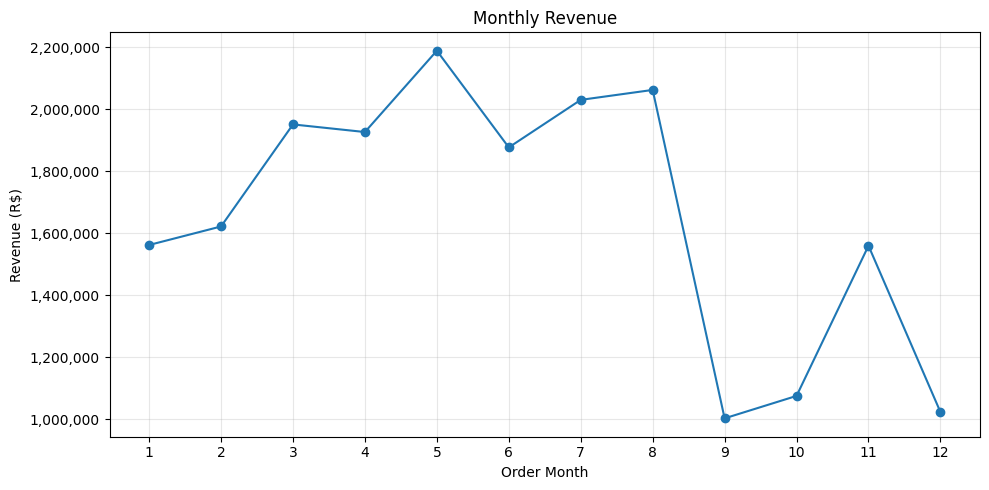

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

monthly_revenue = (fact.groupby("order_month")["payment_value"].sum().reset_index())


# plot graph
plt.figure(figsize=(10, 5))

plt.plot(monthly_revenue["order_month"],monthly_revenue["payment_value"],marker="o")

plt.xlabel("Order Month")
plt.ylabel("Revenue (R$)")
plt.title("Monthly Revenue")

ax = plt.gca()

# Show every month on x-axis
ax.set_xticks(monthly_revenue["order_month"])

# Remove 1e6 and show full numbers with commas
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Monthly Growth

In [ ]:
monthly_revenue

,order_month,payment_value,growth_pct
0,1,1562032.43,NaN
1,2,1621746.59,3.822850
2,3,1950740.83,20.286415
3,4,1926186.64,-1.258711
4,5,2188378.86,13.611984
5,6,1876618.04,-14.246200
6,7,2029877.80,8.166806
7,8,2061955.87,1.580296
8,9,1003132.09,-51.350458
9,10,1075450.97,7.209308


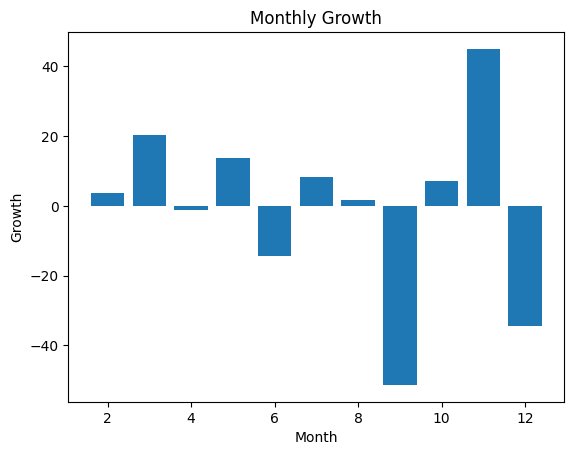

In [ ]:
monthly_revenue["growth_pct"] = (monthly_revenue["payment_value"].pct_change()* 100)

plt.bar(monthly_revenue["order_month"],monthly_revenue["growth_pct"])
plt.title("Monthly Growth")
plt.xlabel("Month")
plt.ylabel("Growth")
plt.show()

## Orders Trend

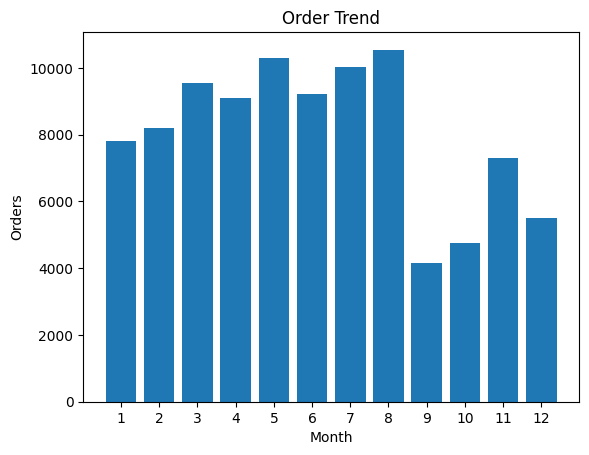

In [ ]:
monthly_orders = (fact.groupby("order_month")["order_id"].nunique().reset_index())



plt.bar(monthly_orders["order_month"],monthly_orders["order_id"])
plt.title("Order Trend")
plt.xlabel("Month")
plt.xticks(monthly_revenue["order_month"])
plt.ylabel("Orders")
plt.show()

## Average Order Value Trend

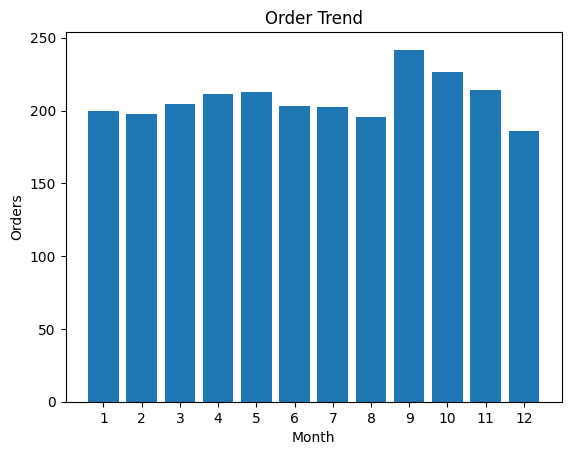

In [ ]:
monthly_aov = (
    fact.groupby("order_month")
    .agg(revenue=("payment_value","sum"),orders=("order_id","nunique")).reset_index())

monthly_aov["aov"] = (monthly_aov["revenue"] / monthly_aov["orders"])

plt.bar(monthly_aov["order_month"],monthly_aov["aov"])
plt.title("Order Trend")
plt.xlabel("Month")
plt.xticks(monthly_revenue["order_month"])
plt.ylabel("Orders")
plt.show()

## Revenue by Product Category

<Axes: xlabel='payment_value', ylabel='product_category_name'>

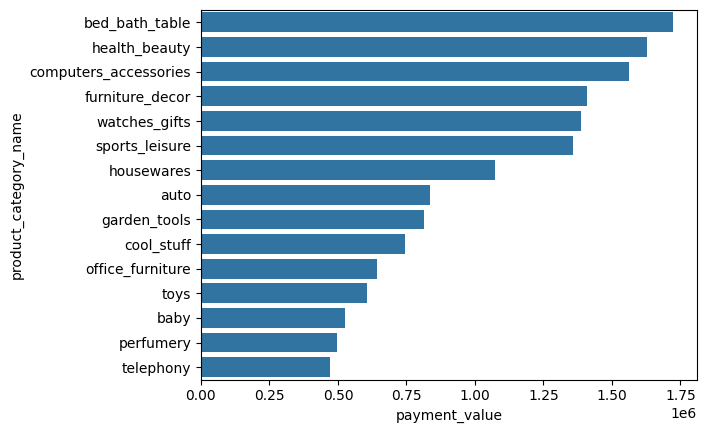

In [ ]:
category_sales = (fact.groupby("product_category_name")["payment_value"].sum()
    .sort_values(ascending=False).reset_index())


top15 = category_sales.head(15)

sns.barplot(data=top15,y="product_category_name",x="payment_value")


## Revenue Concentration

<Axes: xlabel='pct', ylabel='product_category_name'>

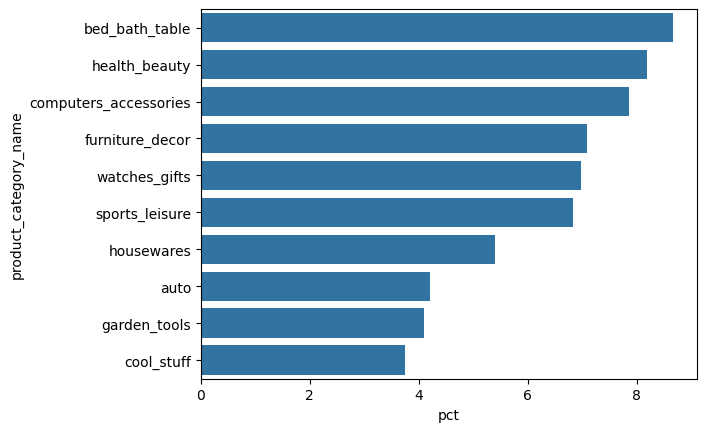

In [ ]:
category_sales["pct"] = (category_sales["payment_value"] / category_sales["payment_value"]
                         .sum() * 100)

top10 = category_sales.head(10)
sns.barplot(data=top10,y="product_category_name",x="pct")


## Geographic Analysis

<Axes: xlabel='customer_state', ylabel='payment_value'>

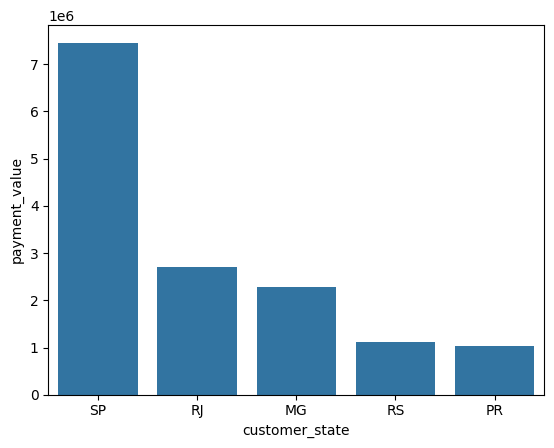

In [ ]:
state_sales = (
    fact
    .groupby("customer_state")["payment_value"].sum().sort_values(ascending=False).reset_index())

top10 = state_sales.head()
sns.barplot(data=top10,y="payment_value",x="customer_state")



## Revenue by Seller State

In [ ]:
seller_state_sales = (
    fact.groupby("seller_state")["payment_value"].sum().sort_values(ascending=False))

seller_state_sales

,payment_value
seller_state,
SP,13094977.02
PR,1812278.65
MG,1521856.91
RJ,1074298.14
SC,854035.85
RS,556238.44
BA,360062.55
DF,134548.53
PE,124494.62


## Pareto Analysis

In [ ]:
customer_revenue = (
    fact
    .groupby("customer_unique_id")["payment_value"].sum()
    .sort_values(ascending=False).reset_index())

customer_revenue["cum_pct"] = (
    customer_revenue["payment_value"].cumsum() / customer_revenue["payment_value"].sum())

customer_revenue[customer_revenue["cum_pct"] <= 0.8]

,customer_unique_id,payment_value,cum_pct
0,0a0a92112bd4c708ca5fde585afaa872,109312.64,0.005499
1,698e1cf81d01a3d389d96145f7fa6df8,45256.00,0.007775
2,c402f431464c72e27330a67f7b94d4fb,44048.00,0.009991
3,4007669dec559734d6f53e029e360987,36489.24,0.011827
4,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00,0.013345
...,...,...,...
39025,64f5a38418a5ccbcda243de650bb8346,135.36,0.799970
39026,7d209a9d69515ea144f57248fa544b7b,135.36,0.799977
39027,b77f478a021da22cd683e0a0d51d7e1f,135.36,0.799983
39028,d763e1a90d84323be3e28d0cc0c20d02,135.36,0.799990


# CUSTOMER ANALYTICS

## Customer Purchase Frequency

In [ ]:
customer_orders = (fact.groupby("customer_unique_id")["order_id"].nunique().reset_index())

customer_orders["order_id"].describe()

,order_id
count,93341.000000
mean,1.033415
std,0.209092
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000


## Repeat Purchase Rate

In [ ]:
repeat_customers = (customer_orders[customer_orders["order_id"] > 1].shape[0])

repeat_rate = (repeat_customers / customer_orders.shape[0] * 100)

repeat_rate

2.999753591669256

## Customer Lifetime Value (CLV)

In [ ]:
clv = (fact.groupby("customer_unique_id")["payment_value"].sum().reset_index())


clv.sort_values("payment_value",ascending=False).head(10)

,customer_unique_id,payment_value
3724,0a0a92112bd4c708ca5fde585afaa872,109312.64
38575,698e1cf81d01a3d389d96145f7fa6df8,45256.00
71555,c402f431464c72e27330a67f7b94d4fb,44048.00
23407,4007669dec559734d6f53e029e360987,36489.24
87431,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00
43164,763c8b1c9c68a0229c42c9fc6f662b93,29099.52
73115,c8460e4251689ba205045f3ea17884a1,27935.46
85749,eae0a83d752b1dd32697e0e7b4221656,25051.89
22391,3d47f4368ccc8e1bb4c4a12dbda7111b,22346.60
63518,adfa1cab2b2c8706db21bb13c0a1beb1,19457.04


## Customer Segmentation

In [ ]:
clv["segment"] = pd.qcut(clv["payment_value"],q=3,labels=["Low","Medium","High"])

clv

,customer_unique_id,payment_value,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,Medium
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low
2,0000f46a3911fa3c0805444483337064,86.22,Medium
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,Low
4,0004aac84e0df4da2b147fca70cf8255,196.89,High
...,...,...,...
93336,fffcf5a5ff07b0908bd4e2dbc735a684,4134.84,High
93337,fffea47cd6d3cc0a88bd621562a9d061,84.58,Medium
93338,ffff371b4d645b6ecea244b27531430a,112.46,Medium
93339,ffff5962728ec6157033ef9805bacc48,133.69,Medium


# RFM ANALYSIS

In [ ]:
# make date and time fields
fact['order_purchase_timestamp'] = pd.to_datetime(fact['order_purchase_timestamp'])
fact['order_approved_at'] = pd.to_datetime(fact['order_approved_at'])
fact['order_delivered_carrier_date'] = pd.to_datetime(fact['order_delivered_carrier_date'])
fact['order_delivered_customer_date'] = pd.to_datetime(fact['order_delivered_customer_date'])
fact['order_estimated_delivery_date'] = pd.to_datetime(fact['order_estimated_delivery_date'])


In [ ]:
snapshot_date = (fact["order_purchase_timestamp"].max() + pd.Timedelta(days=1))


# calculate rfm
rfm = (
    fact.groupby("customer_unique_id")
    .agg({"order_purchase_timestamp":lambda x:(snapshot_date - x.max())
        .days,"order_id":"nunique","payment_value":"sum"}))

# rename columns
rfm.columns = [
    "recency",
    "frequency",
    "monetary"
]


# create scores
rfm["R"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5]
)


# create final scores
rfm["RFM_Score"] = (
    rfm["R"].astype(int)
    +
    rfm["F"].astype(int)
    +
    rfm["M"].astype(int)
)

# create rfm final customer seqment
rfm["Segment"] = pd.qcut(
    rfm["RFM_Score"],
    q=5,
    labels=[
        "Lost Customers",
        "At Risk",
        "Potential Loyalists",
        "Loyal Customers",
        "Champions"])

In [ ]:
rfm.head()

,recency,frequency,monetary,R,F,M,RFM_Score,Segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,9,Potential Loyalists
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,6,Lost Customers
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,4,Lost Customers
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,4,Lost Customers
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,7,Lost Customers
